In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,classification_report
#generate synthetic dataset
np.random.seed(42)
n_samples=200
X=np.random.rand(n_samples,2)*10
y=(X[:,0]*1.5+X[:,1]>15).astype(int)

#create dataFrame  
df=pd.DataFrame(X,columns=['Age','Salary'])
df['purchase']=y
#SPLIT DATA

x_train,x_test,y_train,y_test=train_test_split(df[['Age','Salary']],df['purchase'],test_size=0.2,random_state=42)
#train logistic model
model=LogisticRegression()
model.fit(x_train,y_train)

#make prediction
y_pred=model.predict(x_test)
#model performance
#decion boundry mean threshold when using sigmoid like activation function .for signmoid 
#convert to 0 - 1 range ,then decision boundary means 0.5
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Accuracy:",recall_score(y_test,y_pred))
print("Accuracy:",f1_score(y_test,y_pred))
print("\n classification report:\n",classification_report(y_test,y_pred) )    

Accuracy: 1.0
Precision: 1.0
Accuracy: 1.0
Accuracy: 1.0

 classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        14

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [30]:
import matplotlib.pyplot as plt
#plot decison boundary
#x_min,x_max=df['Age'].min()-1,df['Age'].max()+1
#y_min,y_max=df['Salary'].min()-1,df['Salary'].max()+1
x_min,x_max=X[:,0].min()-1,X[:,0].max()+1 #first column X[:,0]
y_min,y_max=X[:,1].min()-1,X[:,1].max()+1  #second column X[:,1]
xx,yy=np.meshgrid(np.arange(x_min,x_max,0.1),np.arange(y_min,y_max,0.1))

In [31]:
#predict probabilities for grid points
z=model.predict(np.c_[xx.ravel(),yy.ravel()])
z=z.reshape(xx.shape)

D:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


C:\Users\HP\AppData\Local\Temp\ipykernel_10188\1811723134.py:2: UserWarning: The following kwargs were not used by contour: 'aplha'
  plt.contourf(xx,yy,z,aplha=0.8,cmap="coolwarm")


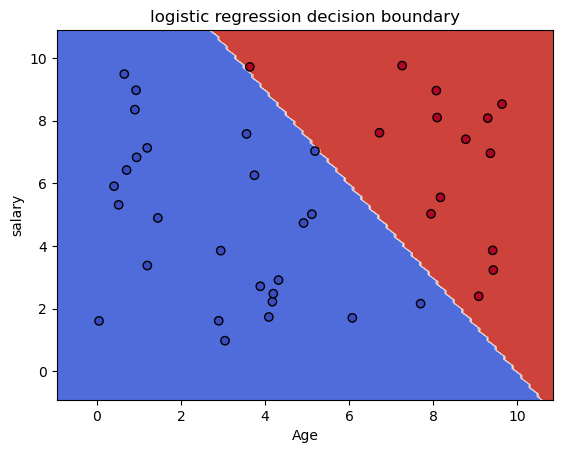

In [32]:
#plot
plt.contourf(xx,yy,z,aplha=0.8,cmap="coolwarm")
plt.scatter(x_test['Age'],x_test["Salary"],c=y_test,edgecolor="k",cmap="coolwarm")
plt.title("logistic regression decision boundary")
plt.xlabel('Age')
plt.ylabel('salary')
plt.show()
